# Thu thập dữ liệu

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import norm
from scipy.stats import ks_2samp, chi2_contingency
import gdown
import warnings
warnings.filterwarnings('ignore')

In [10]:
drive_files = {
    'orders': '1qgJAYEH1M5w5syZCHsCof4v5yYHDglZ8',
    'products': '1ChaIE-mxZusnsUN3uPQLzrgO8iWFFB_o',
    'items': '189g8Scbtk_bwKeLgu1V93UMw9uMWYcC_',
    'sales': '1wymVLHfIkObDNZDbG5OKauIpZF8_7srT',
    'web_traffic': '1YwWikoZJyQYEMrcc--CNweJF_wZ-9HF5',
    'customers': '1zOJVpKAvyZDhjrv8oN5X3q-8ESt7nK0C',
}

dfs = {}

print("Đang tải dữ liệu, vui lòng đợi...")
for name, file_id in drive_files.items():
    url = f'https://drive.google.com/uc?export=download&id={file_id}'
    dfs[name] = pd.read_csv(url)
    print(f"Đã tải xong: {name}")

orders = dfs['orders']
products = dfs['products']
items = dfs['items']
sales = dfs['sales']
web_traffic = dfs['web_traffic']
customers = dfs['customers']

Đang tải dữ liệu, vui lòng đợi...
Đã tải xong: orders
Đã tải xong: products
Đã tải xong: items
Đã tải xong: sales
Đã tải xong: web_traffic
Đã tải xong: customers


In [11]:
display(orders.head())

display(products.head())

display(items.head())

display(sales.head())

display(web_traffic.head())

display(customers.head())


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


In [12]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
sales['Date'] = pd.to_datetime(sales['Date'])
sales['quarter'] = sales['Date'].dt.to_period('Q').astype(str)
items['net_revenue'] = (items['quantity'] * items['unit_price'])

# Phân tích doanh thu

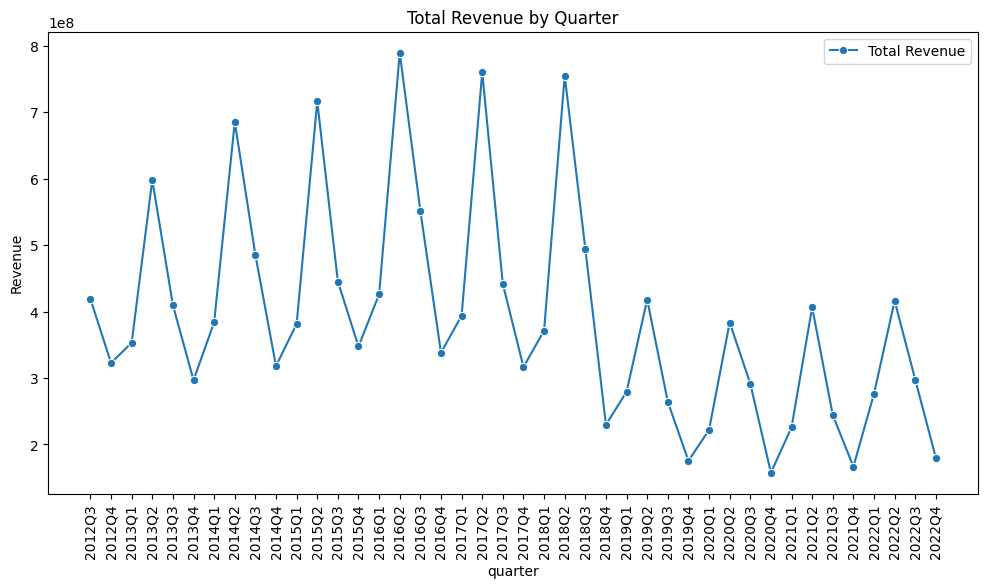

In [13]:
quarterly_revenue = sales.groupby('quarter')['Revenue'].sum().reset_index()
quarterly_revenue['quarter'] = quarterly_revenue['quarter'].astype(str)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(data=quarterly_revenue, x='quarter', y='Revenue', marker='o', label='Total Revenue')
plt.title('Total Revenue by Quarter')
plt.xticks(rotation=90)
plt.show()

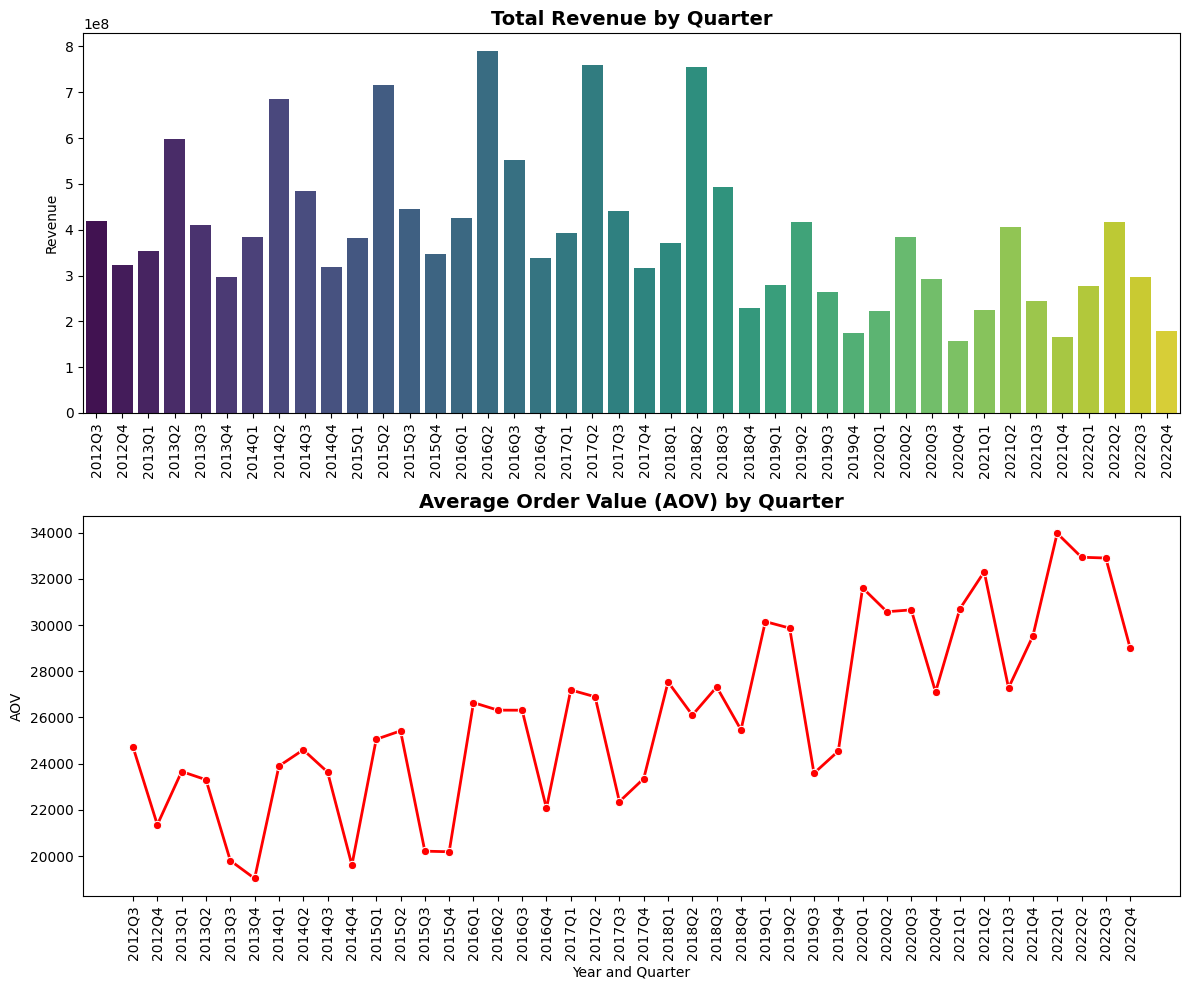

In [14]:
# Hợp nhất và xử lý thời gian
df_combined = pd.merge(items, orders[['order_id', 'order_date']], on='order_id')

# Gom nhóm theo chu kỳ 3 tháng (Quý)
# Dùng 'QE' để lấy mốc cuối quý chính xác
quarterly_data = df_combined.set_index('order_date').resample('QE').agg({
    'net_revenue': 'sum',
    'order_id': 'nunique'
}).reset_index()

# Tính AOV và gắn nhãn Quý
quarterly_data['aov'] = quarterly_data['net_revenue'] / quarterly_data['order_id']
quarterly_data['quarter_label'] = quarterly_data['order_date'].dt.to_period('Q').astype(str)

#  Vẽ 2 biểu đồ riêng biệt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- Biểu đồ 1: Tổng Doanh thu thuần theo Quý ---
sns.barplot(data=quarterly_data, x='quarter_label', y='net_revenue', ax=ax1, palette='viridis', hue='quarter_label', legend=False)
ax1.set_title('Total Revenue by Quarter', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue')
ax1.set_xlabel('') # Ẩn nhãn x ở biểu đồ trên cho gọn

# --- Biểu đồ 2: Giá trị đơn hàng trung bình (AOV) theo Quý ---
sns.lineplot(data=quarterly_data, x='quarter_label', y='aov', ax=ax2, marker='o', color='red', linewidth=2)
ax2.set_title('Average Order Value (AOV) by Quarter', fontsize=14, fontweight='bold')
ax2.set_ylabel('AOV')
ax2.set_xlabel('Year and Quarter')

# Tự động căn chỉnh khoảng cách giữa các biểu đồ
ax1.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

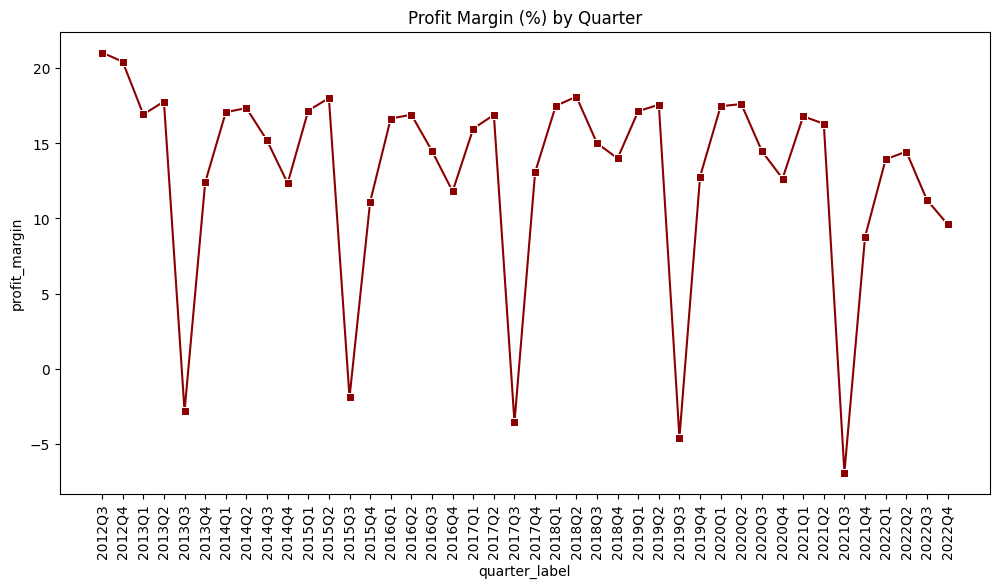

In [15]:
quarterly_profit = sales.set_index('Date').resample('QE').agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# Tính lợi nhuận và biên lợi nhuận
quarterly_profit['gross_profit'] = quarterly_profit['Revenue'] - quarterly_profit['COGS']
quarterly_profit['profit_margin'] = (quarterly_profit['gross_profit'] / quarterly_profit['Revenue']) * 100
quarterly_profit['quarter_label'] = quarterly_profit['Date'].dt.to_period('Q').astype(str)

# Trực quan hóa Lợi nhuận và Biên lợi nhuận
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=quarterly_profit, x='quarter_label', y='profit_margin', ax=ax1, color='darkred', marker='s')

ax1.set_title('Profit Margin (%) by Quarter')
ax1.tick_params(axis='x', rotation=90)
plt.show()

1.
- Doanh thu đang "tụt dốc không phanh": Doanh thu có tính chu kỳ rất mạnh, thường đạt đỉnh vào Quý 2 hàng năm.

- Suy thoái (2019 - 2022): Sau năm 2018, các "đỉnh" doanh thu thấp dần. Đến năm 2022, doanh thu quý cao nhất cũng chỉ quanh mức 400 triệu VNĐ, và quý thấp nhất rơi xuống dưới 200 triệu VNĐ.

Kết luận: Quy mô dòng tiền của doanh nghiệp đang thu hẹp lại đáng kể.

2.
- Nghịch lý: Giá trị đơn hàng (AOV) tăng nhưng Doanh thu giảm (Biểu đồ 2)
Trong khi doanh thu tổng giảm, thì giá trị mỗi đơn hàng lại tăng trưởng đều đặn.
- Điều này có nghĩa là: Bạn đang bán được ít đơn hàng hơn rất nhiều so với trước đây. Dù khách hàng chi nhiều tiền hơn trên mỗi lần mua (có thể do tăng giá bán hoặc khách mua combo), nhưng lượng khách hàng mới hoặc tần suất mua hàng đang sụt giảm nghiêm trọng, không đủ bù đắp cho sự sụt giảm về số lượng đơn.

3.
- Biên lợi nhuận cực kỳ bất ổn và có dấu hiệu "âm" nặng (Biểu đồ 3)
Đây là phần đáng lo ngại nhất. Biên lợi nhuận thường duy trì ở mức 15% - 20%, nhưng cứ cách một khoảng thời gian lại xuất hiện các cú "rơi tự do" xuống mức âm:
- Nhận định: Cứ vào Quý 3 hàng năm, doanh nghiệp dường như gặp vấn đề cực lớn về chi phí hoặc chiến dịch giảm giá sâu. Việc biên lợi nhuận âm trong khi doanh thu cũng đang thấp cho thấy doanh nghiệp đang phải "gồng lỗ" để duy trì vận hành trong các giai đoạn này.

# PHÂN TÍCH AOV

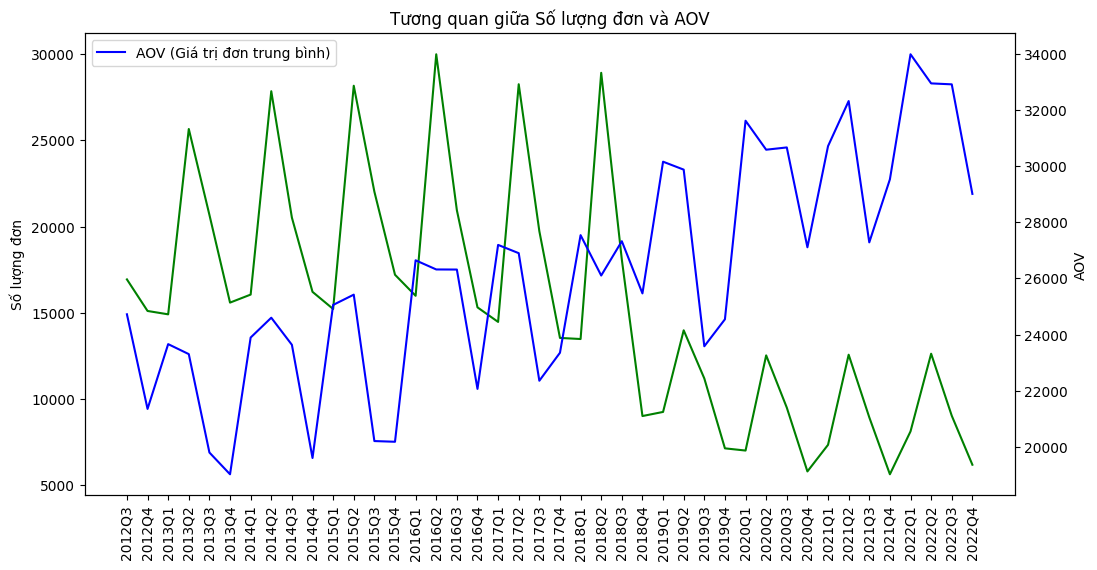

In [16]:
# Groupby theo order_id để có tổng tiền mỗi đơn hàng
order_revenue = items.groupby('order_id')['net_revenue'].sum().reset_index()
# 3. Merge với bảng orders để lấy thông tin ngày tháng (Quarter)
orders_full = pd.merge(orders, order_revenue, on='order_id', how='left')

# Tính số lượng đơn hàng và doanh thu trung bình mỗi đơn theo quý
orders_full['order_date'] = pd.to_datetime(orders_full['order_date'])
orders_full['quarter'] = orders_full['order_date'].dt.to_period('Q').astype(str)
check_vols = orders_full.groupby('quarter').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('net_revenue', 'sum')
)
check_vols['AOV'] = check_vols['total_revenue'] / check_vols['total_orders']

# Vẽ biểu đồ tương quan
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(check_vols.index, check_vols['total_orders'], color='g', label='Số lượng đơn hàng')
ax2.plot(check_vols.index, check_vols['AOV'], color='b', label='AOV (Giá trị đơn trung bình)')
ax1.set_ylabel('Số lượng đơn'), ax2.set_ylabel('AOV')
ax1.tick_params(axis='x', rotation=90)
plt.title('Tương quan giữa Số lượng đơn và AOV')
plt.legend()
plt.show()

- Hướng 1: Tại sao từ Q4
/2018, số lượng đơn và doanh thu giảm nhưng AOV tăng?
- Hướng 2: Tại sao luôn có 1 đợt sụt giảm vào Q3 hàng năm

# Hướng 1

Các kịch bản có thể xảy ra:
1. Kịch bản "Bẫy Combo" và Sự kiệt quệ của khách hàng cũ: Doanh nghiệp liên tục tung ra các gói Bundle (mua 3 tặng 1, mua combo tiết kiệm). Tại sao xảy ra: Việc bán combo khiến khách hàng mua một lúc nhiều món, làm AOV tăng vọt dù số đơn giảm. Nhưng vì khách đã mua quá nhiều một lúc, họ không cần quay lại trong thời gian dài (tần suất mua giảm), hoặc khách hàng mới thấy giá combo quá cao nên không dám thử. Hệ quả: Lượng đơn hàng mới giảm dần, doanh nghiệp chỉ còn sống dựa vào một nhóm nhỏ khách hàng sẵn lòng chi đậm, nhưng nhóm này cũng đang ít dần đi.

2. Kịch bản "Sản phẩm lỗi thời" (Product Life Cycle Decline): Sản phẩm cốt lõi của bạn đã lỗi thời. Để duy trì doanh thu, doanh nghiệp cố gắng "vắt chanh" những khách hàng còn sót lại bằng cách bán thêm (upsell/cross-sell) khiến AOV tăng. Hệ quả: Đây là dấu hiệu của một thương hiệu đang già hóa và không thu hút được Gen Z hoặc tệp khách hàng mới.

3. Kịch bản "Đuổi khách bằng giá" (Price Elasticity Failure): Doanh nghiệp có thể đã tăng giá bán niêm yết hoặc cắt giảm các gói sản phẩm giá rẻ để tập trung vào phân khúc cao cấp hơn. Hệ quả: Khách hàng phải chi nhiều tiền hơn cho mỗi lần mua ($AOV \uparrow$). Tuy nhiên, sản phẩm/dịch vụ không chất lượng hoặc không còn tính cạnh tranh ở mức giá mới, dẫn đến khách hàng đại trà rời bỏ bạn ($Volume \downarrow$). Số lượng khách rời đi nhiều hơn tốc độ tăng giá, khiến tổng doanh thu bị thu hẹp.




## Kịch bản 1: Combo

**Tóm tắt kịch bản:** Khách hàng có thể đang chuyển dịch từ việc "mua lẻ tẻ nhiều lần" sang "mua một lần thật nhiều" (có thể do chính sách Combo hoặc yêu cầu giá trị đơn tối thiểu để fresship).
- Tại sao AOV tăng: Khách hàng dồn đơn. Thay vì mỗi tuần mua 1 món (AOV thấp), họ đợi 1 tháng mua 4 món một lúc (AOV cao).
- Tại sao Số đơn giảm: Vì họ dồn đơn nên tổng số lần phát sinh giao dịch (Order Count) giảm xuống.
- Tại sao doanh thu tổng vẫn giảm: Vì khi dồn đơn, tổng nhu cầu thực tế của họ thường bị cắt giảm. Khách hàng có xu hướng cân nhắc kỹ hơn và loại bỏ những món "mua cho vui" khi phải thanh toán một hóa đơn lớn.
- Dấu hiệu: UPT (Units per Transaction) tăng, khách hàng dồn đơn.



In [17]:
orders['quarter'] = orders['order_date'].dt.to_period('Q').astype(str)

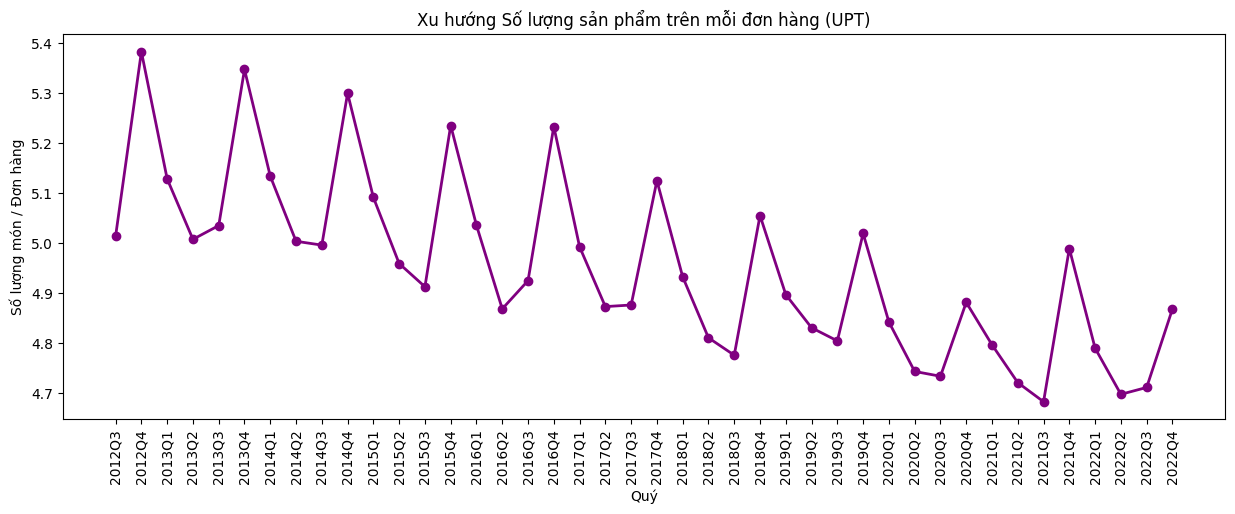

In [18]:
# Tính số lượng sản phẩm trung bình trên mỗi đơn hàng (UPT)
upt_analysis = items.groupby('order_id')['quantity'].sum().reset_index()
upt_with_date = pd.merge(upt_analysis, orders[['order_id', 'quarter']], on='order_id')

upt_trend = upt_with_date.groupby('quarter')['quantity'].mean()

# Vẽ biểu đồ UPT
plt.figure(figsize=(15, 5))
plt.plot(upt_trend.index, upt_trend.values, marker='o', color='purple', linewidth=2)
plt.title('Xu hướng Số lượng sản phẩm trên mỗi đơn hàng (UPT)')
plt.ylabel('Số lượng món / Đơn hàng')
plt.xlabel('Quý')
plt.xticks(rotation=90)
plt.show()

UPT giảm, do đó kịch bản dồn đơn khó có thể xảy ra

## Kịch bản 2: Sản phẩm lỗi thời

**Tóm tắt kịch bản:**: Sản phẩm cốt lõi đã bước vào giai đoạn suy thoái của vòng đời. Doanh nghiệp không thu hút được khách hàng mới mà đang cố gắng khai thác tối đa giá trị còn lại từ nhóm khách hàng cũ trung thành.
- Tại sao AOV tăng: Doanh nghiệp thực hiện tăng giá niêm yết hoặc tập trung đẩy các dòng sản phẩm phiên bản đặc biệt, cao cấp hơn của danh mục cũ. Khách hàng trung thành sẵn sàng chi trả mức giá cao hơn cho những món đồ mang tính biểu tượng của thương hiệu.
- Tại sao Số đơn giảm: Thương hiệu bị "lão hóa" và mất tính thời thượng, dẫn đến tỷ lệ khách hàng mới gia nhập hệ thống cực thấp. Đồng thời, khách hàng cũ giảm tần suất mua sắm vì sản phẩm không còn đột phá về thiết kế.
- Tại sao doanh thu tổng vẫn giảm: Sự gia tăng về giá bán trên mỗi đơn (AOV) không đủ sức bù đắp cho sự sụt giảm nghiêm trọng về lượng khách hàng (Traffic/Volume). Doanh nghiệp đang nhỏ lại dần theo đà suy thoái của dòng sản phẩm chính.
- Tại sao UPT giảm? Khách hàng trung thành còn sót lại hiện chỉ mua đúng món họ cần (ví dụ: một chiếc áo khoác biểu tượng) thay vì mua cả set đồ như thời hoàng kim. Những khách hàng "mua theo trend" đã biến mất.
- Dấu hiệu: Sự suy giảm doanh thu của nhóm sản phẩm chủ đạo

<Figure size 1200x800 with 0 Axes>

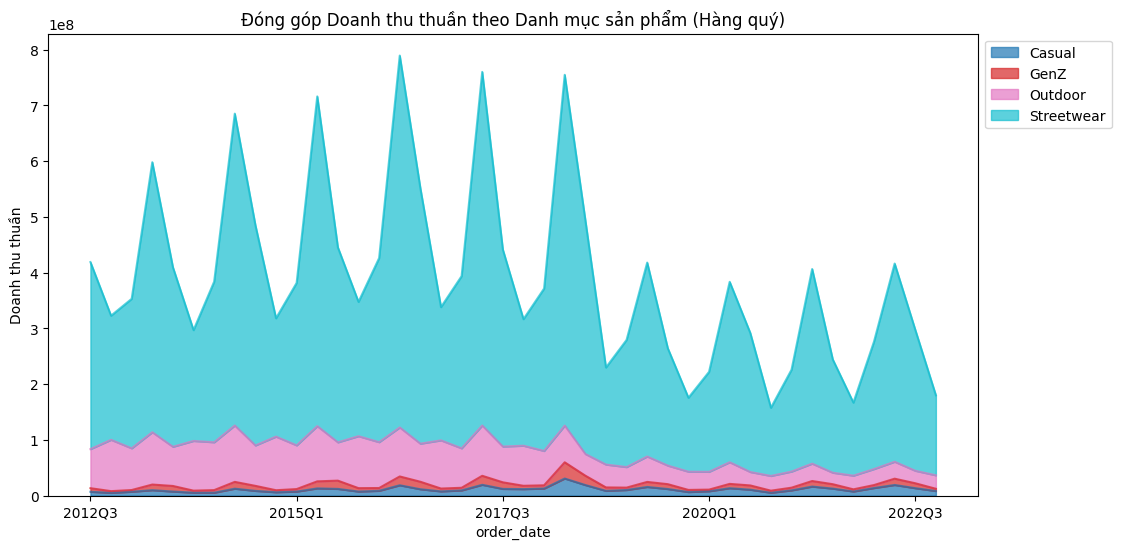

In [19]:
# 1. Kết hợp thêm bảng Product để lấy thông tin Category
df_category = pd.merge(items, products[['product_id', 'category']], on='product_id')
df_category = pd.merge(df_category, orders[['order_id', 'order_date']], on='order_id')

# 2. Group by theo Quý và Category
quarterly_cat = df_category.set_index('order_date').groupby([
    pd.Grouper(freq='QE'), 'category'
])['net_revenue'].sum().unstack().fillna(0)

# 3. Vẽ biểu đồ miền (Stacked Area Chart) để thấy sự thay đổi tỷ trọng
plt.figure(figsize=(12, 8))
quarterly_cat.index = quarterly_cat.index.to_period('Q').astype(str)
quarterly_cat.plot(kind='area', stacked=True, figsize=(12, 6), colormap='tab10', alpha=0.7)
plt.title('Đóng góp Doanh thu thuần theo Danh mục sản phẩm (Hàng quý)')
plt.ylabel('Doanh thu thuần')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

1. Sự sụp đổ của "Động cơ tăng trưởng" chính (Streetwear): Các đỉnh doanh thu của Streetwear thấp dần đều, sản phẩm "đinh" đã bị lỗi thời hoặc bão hòa.

2. Để đối phó với sự sụt giảm của Streetwear, doanh nghiệp dường như đã cố gắng đưa vào các dòng sản phẩm mới như GenZ (màu đỏ) và Outdoor (màu hồng):
- Tỷ trọng quá nhỏ: Dù được đưa vào nhưng đóng góp doanh thu của các nhóm này cực kỳ khiêm tốn và không có dấu hiệu bứt phá.

- GenZ (đường màu đỏ): Gần như "phẳng" từ năm 2012 đến 2022. Điều này chứng minh thương hiệu hoàn toàn không thu hút được tệp khách hàng trẻ.

## Kịch bản 3: Tăng giá

**Tóm tắt kịch bản:**: Doanh nghiệp chủ động tăng giá niêm yết để cải thiện biên lợi nhuận hoặc chuyển mình sang phân khúc cao cấp hơn, nhưng giá trị cảm nhận của khách hàng về sản phẩm không tăng tương ứng.

- Tại sao AOV tăng: Do đơn giá mỗi món đồ trong giỏ hàng đều cao hơn trước. Dù khách hàng mua ít món đi, nhưng vì mỗi món đều đắt hơn đáng kể nên tổng giá trị hóa đơn trung bình (AOV) vẫn bị kéo lên cao.

- Tại sao Số đơn giảm: Nhóm khách hàng nhạy cảm về giá (nhóm bình dân - vốn chiếm số đông) lập tức rời bỏ thương hiệu để tìm kiếm giải pháp thay thế rẻ hơn. Tốc độ mất khách nhanh hơn nhiều so với tốc độ tăng trưởng giá.

- Tại sao doanh thu tổng vẫn giảm: Tổng doanh thu sụt giảm vì sự gia tăng của AOV không đủ bù đắp cho sự sụt giảm quá lớn về số lượng giao dịch (Order Count).

- Tại sao UPT giảm: Khách hàng thắt chặt hầu bao, chỉ mua đúng sản phẩm "cần nhất" và cắt bỏ các sản phẩm "mua kèm" do tổng giá trị đơn hàng đã chạm ngưỡng chi trả tối đa của họ.

- Dấu hiệu: Sự tăng lên của giá niêm yết sản phẩm.


In [20]:
items_copy = items.copy()
items_copy['original_price'] = items_copy['unit_price'] + items_copy['discount_amount']
items_copy

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,net_revenue,original_price
0,1,2400,7,1138.22,0.0,NaN,NaN,7967.54,1138.22
1,2,609,7,10166.25,0.0,NaN,NaN,71163.75,10166.25
2,3,396,3,11220.33,0.0,NaN,NaN,33660.99,11220.33
3,4,635,5,10639.25,0.0,NaN,NaN,53196.25,10639.25
4,6,1935,1,1597.84,0.0,NaN,NaN,1597.84,1597.84
...,...,...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NaN,NaN,35791.36,4473.92
714665,834377,1995,7,5250.79,0.0,NaN,NaN,36755.53,5250.79
714666,834387,2331,8,7389.06,0.0,NaN,NaN,59112.48,7389.06
714667,834392,1115,5,4767.33,0.0,NaN,NaN,23836.65,4767.33


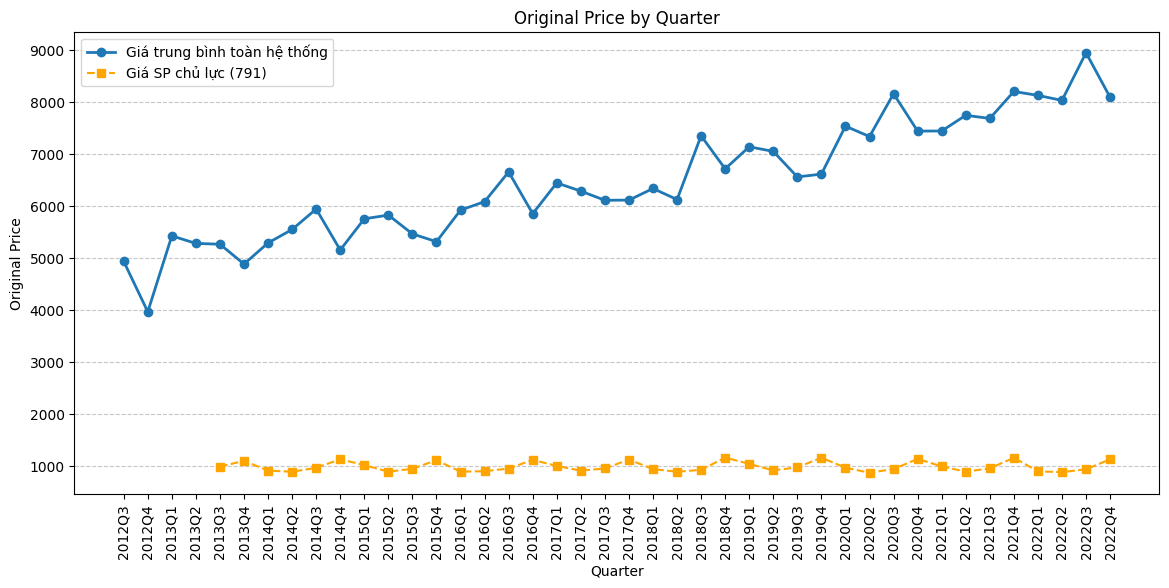

In [22]:
# Bước 1: Kết hợp để lấy thông tin thời gian
df_price = pd.merge(items_copy[['order_id',	'product_id',	'quantity',	'unit_price',	'discount_amount', 'original_price']], orders[['order_id', 'quarter']], on='order_id')

# Bước 2: Tính giá bán trung bình (trước chiết khấu) theo từng quý
price_trend = df_price.groupby('quarter')['original_price'].mean().reset_index()

# Bước 3: Lọc ra 1 sản phẩm cụ thể để xem cho chính xác
top_product_id = items_copy.groupby('product_id')['quantity'].sum().idxmax()
top_prod_trend = df_price[df_price['product_id'] == top_product_id].groupby('quarter')['original_price'].mean().reset_index()

# Bước 4: Vẽ biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ xu hướng giá trung bình toàn hệ thống
plt.plot(price_trend['quarter'], price_trend['original_price'], marker='o', label='Giá trung bình toàn hệ thống', linewidth=2)

# Vẽ xu hướng của sản phẩm chủ lực
plt.plot(top_prod_trend['quarter'], top_prod_trend['original_price'], marker='s', ls='--', label=f'Giá SP chủ lực ({top_product_id})', color='orange')

plt.xticks(rotation=90)
plt.title('Original Price by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Original Price')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Số lượng ID tìm được: 10


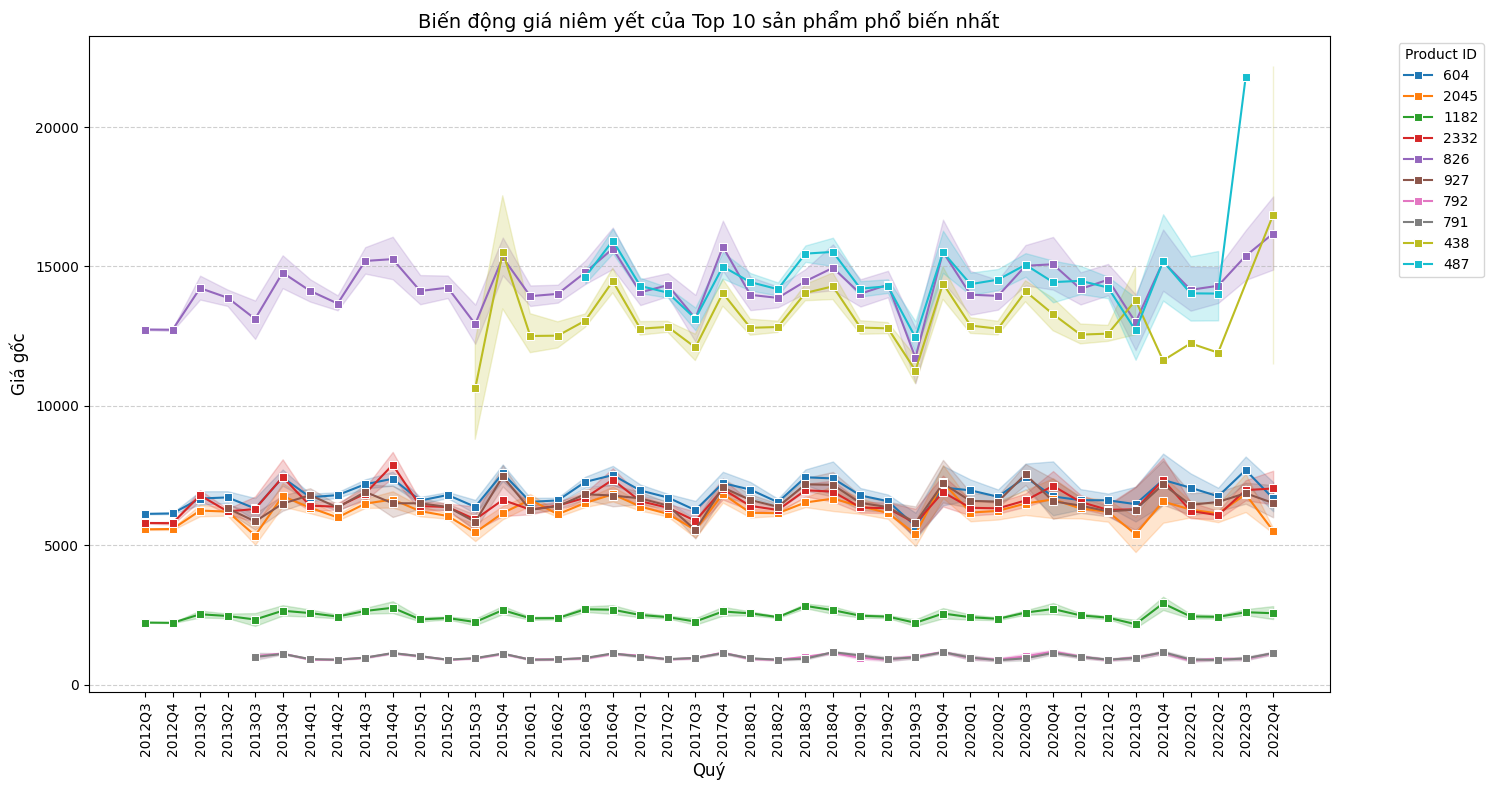

In [24]:
# 1. Tìm Top 10 sản phẩm phổ biến nhất
top_10_products = items_copy.groupby('product_id')['quantity'].sum().nlargest(10).index.tolist()
print(f"Số lượng ID tìm được: {len(top_10_products)}")


# 2. Chuẩn bị dữ liệu: Merge với bảng orders để lấy mốc thời gian (Quarter)
df_top10 = pd.merge(
    items_copy[items_copy['product_id'].isin(top_10_products)],
    orders[['order_id', 'quarter']],
    on='order_id'
)
df_top10['product_id'] = df_top10['product_id'].astype(str)

# 3. Tính giá trung bình mỗi quý cho từng sản phẩm trong Top 10
price_trend_top10 = df_top10.groupby(['quarter', 'product_id'])['original_price'].mean().unstack()

# 4. Vẽ biểu đồ
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_top10, x='quarter', y='original_price', hue='product_id', marker='s')

plt.title('Biến động giá niêm yết của Top 10 sản phẩm phổ biến nhất', fontsize=14)
plt.xlabel('Quý', fontsize=12)
plt.ylabel('Giá gốc', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Product ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Nhận xét: Ngoại trừ các mặt hàng phổ biến nhất, doanh nghiệp duy trì mức giá ổn định cho các mặt hàng phổ biến khác để giữ chân khách hàng cũ, tuy nhiên trung bình giá niêm yết vẫn tăng, chứng tỏ các sản phẩm mới được đưa vào hệ thống ở phân khúc giá cao hơn. Điều này khớp với phân tích trước đó cho rằng các mặt hàng cũ đang dần bị bão hòa. Dù giá không tăng nhiều, nhưng các mặt hàng phổ biến này đã lỗi thời, không còn đủ sức kéo khách hàng mới vào hệ thống, dẫn đến số đơn giảm. Khách hàng ưa chuộng các mặt hàng phổ biến nhất có thể không chấp nhận được sự tăng giá của chúng, nên từ bỏ thương hiệu, dẫn đến số đơn và doanh thu đều giảm.

-> Nhóm hàng phổ biến thì không còn ai mua (do lỗi thời), còn nhóm hàng mới giá cao thì không có đủ khách hàng mới bù đắp. Doanh thu từ nhóm hàng đắt tiền (làm tăng AOV) không đủ lớn để cứu vãn sự sụt giảm số lượng đơn hàng khủng khiếp từ nhóm hàng bình dân.

Số lượng ID tìm được: 10


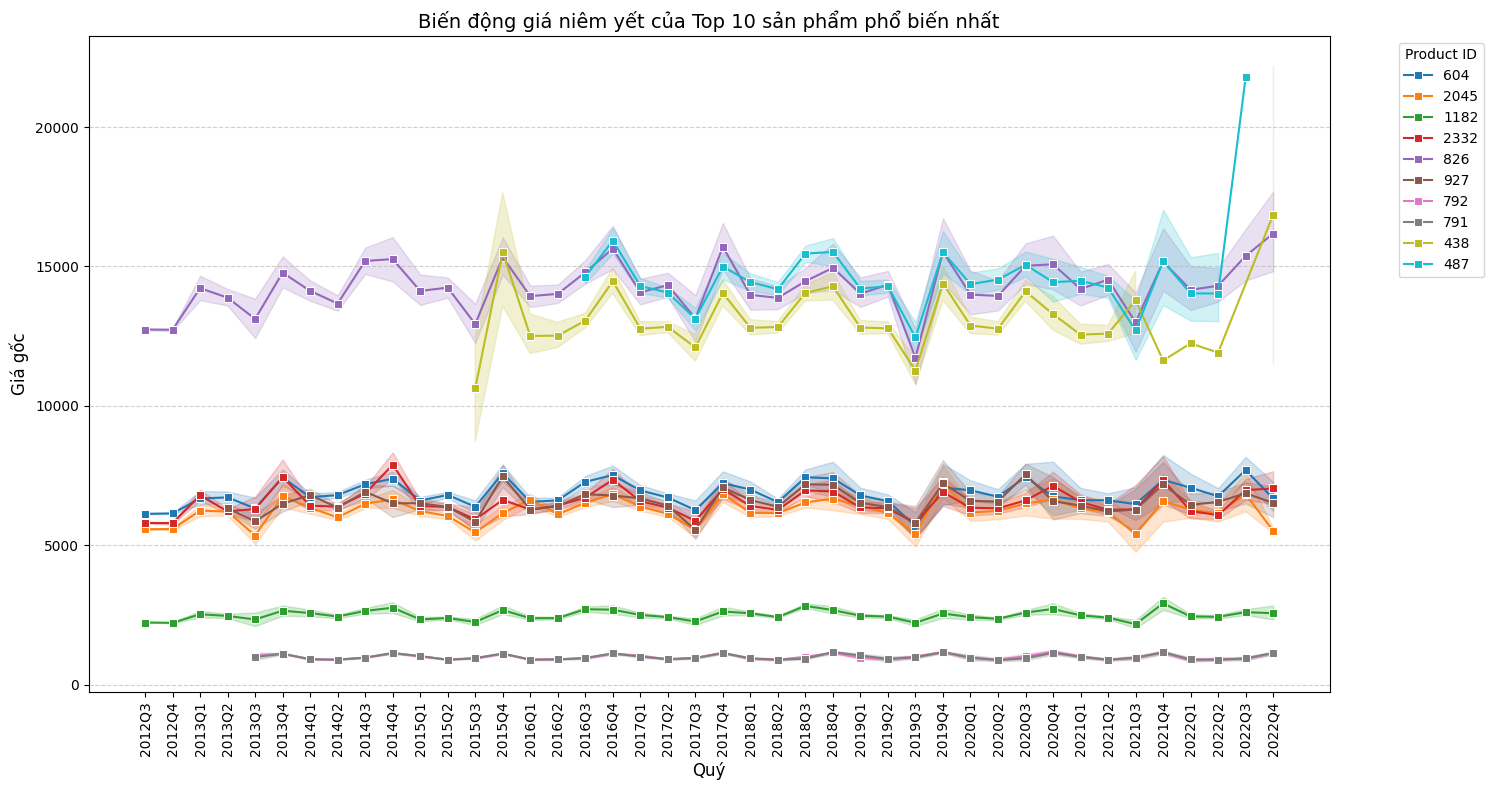

In [25]:
# 1. Tìm Top 10 sản phẩm phổ biến nhất
top_10_products = items_copy.groupby('product_id')['quantity'].sum().nlargest(10).index.tolist()
print(f"Số lượng ID tìm được: {len(top_10_products)}")


# 2. Chuẩn bị dữ liệu: Merge với bảng orders để lấy mốc thời gian (Quarter)
df_top10 = pd.merge(
    items_copy[items_copy['product_id'].isin(top_10_products)],
    orders[['order_id', 'quarter']],
    on='order_id'
)
df_top10['product_id'] = df_top10['product_id'].astype(str)

# 3. Tính giá trung bình mỗi quý cho từng sản phẩm trong Top 10
price_trend_top10 = df_top10.groupby(['quarter', 'product_id'])['original_price'].mean().unstack()

# 4. Vẽ biểu đồ
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_top10, x='quarter', y='original_price', hue='product_id', marker='s')

plt.title('Biến động giá niêm yết của Top 10 sản phẩm phổ biến nhất', fontsize=14)
plt.xlabel('Quý', fontsize=12)
plt.ylabel('Giá gốc', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Product ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

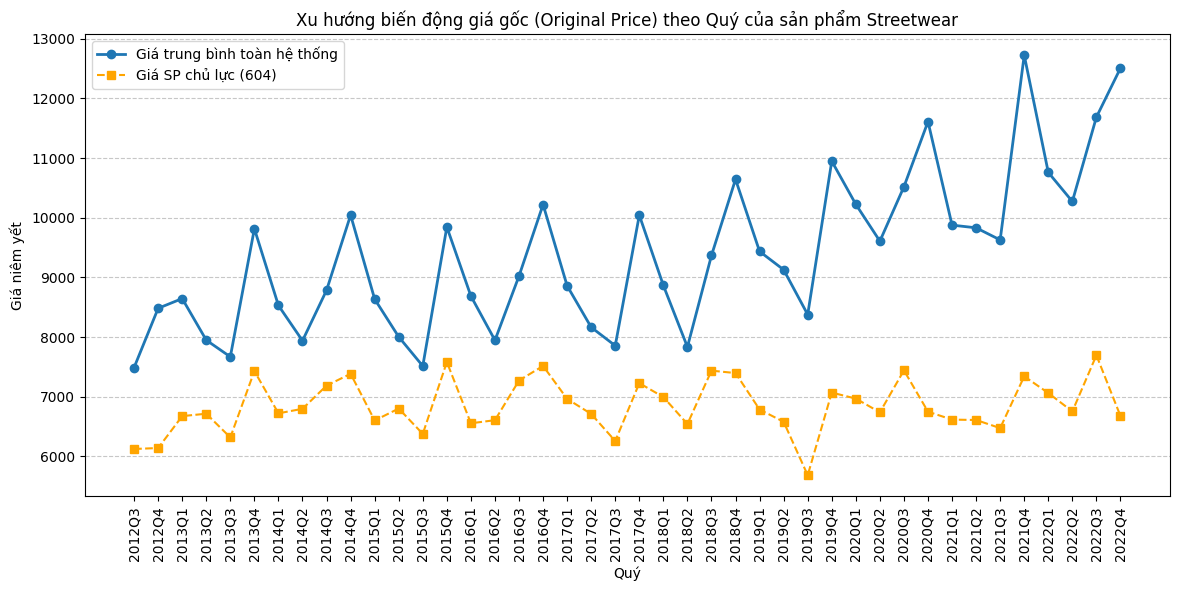

In [26]:
# Bước 1: Kết hợp để lấy thông tin thời gian
product_list = products.loc[products['category'].isin(['Streetwear']), 'product_id'].to_list()
df_price = pd.merge(items_copy[['order_id',	'product_id',	'quantity',	'unit_price',	'discount_amount', 'original_price']], orders[['order_id', 'quarter']], on='order_id')
df_price = df_price[df_price['product_id'].isin(product_list)]

# Bước 2: Tính giá bán trung bình (trước chiết khấu) theo từng quý
price_trend = df_price.groupby('quarter')['original_price'].mean().reset_index()

# Bước 3: Lọc ra 1 sản phẩm cụ thể để xem cho chính xác
top_product_id = df_price.groupby('product_id')['quantity'].sum().idxmax()
top_prod_trend = df_price[df_price['product_id'] == top_product_id].groupby('quarter')['original_price'].mean().reset_index()

# Bước 4: Vẽ biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ xu hướng giá trung bình toàn hệ thống
plt.plot(price_trend['quarter'], price_trend['original_price'], marker='o', label='Giá trung bình toàn hệ thống', linewidth=2)

# Vẽ xu hướng của sản phẩm chủ lực
plt.plot(top_prod_trend['quarter'], top_prod_trend['original_price'], marker='s', ls='--', label=f'Giá SP chủ lực ({top_product_id})', color='orange')

plt.xticks(rotation=90)
plt.title('Xu hướng biến động giá gốc (Original Price) theo Quý của sản phẩm Streetwear')
plt.xlabel('Quý')
plt.ylabel('Giá niêm yết')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Nhận xét: Nhóm Streetwear mang lại doanh thu chính và có sự tăng giá trung bình, đây là 1 nguyên nhân khiến số đơn hàng giảm (cầu đối với sản phẩm của doanh nghiệp giảm). Nguyên nhân này có thể do chi phí sản xuất tăng, cần tiến hành kiểm tra và xác định gốc rễ nếu có vấn đề về quá trình vận hành khiến chi phí sản xuất tăng.

# Tính tỷ lệ chuyển đổi (Conversion Rate) theo quý

In [27]:
# BƯỚC 1: Xử lý bảng Orders (Đếm số đơn hàng theo Quý)
orders_agg = orders.groupby('quarter').agg(
    total_orders=('order_id', 'nunique') # Dùng nunique để tương đương DISTINCTCOUNT
).reset_index()

# ---------------------------------------------------------
# BƯỚC 2: Xử lý bảng Web Traffic (Tạo cột Quarter và Tính tổng)
# Chuyển cột date sang định dạng datetime (nếu chưa phải)
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

# Tạo cột 'quarter' với định dạng string giống hệt bảng orders (VD: '2022Q1')
web_traffic['quarter'] = web_traffic['date'].dt.to_period('Q').dt.strftime('%YQ%q')

# Tính tổng các chỉ số traffic theo quý
traffic_agg = web_traffic.groupby('quarter').agg(
    total_sessions=('sessions', 'sum'),
    total_unique_visitors=('unique_visitors', 'sum'),
    total_page_views=('page_views', 'sum') # Tính thêm nếu cần
).reset_index()

# ---------------------------------------------------------
# BƯỚC 3: Join 2 bảng và Tính Conversion Rate
# Sử dụng LEFT JOIN hoặc OUTER JOIN để đảm bảo không mất quý nào
print(traffic_agg.shape)
print(orders_agg.shape)
final_df = pd.merge(traffic_agg, orders_agg, on='quarter', how='left')

# Xử lý các giá trị NaN (ví dụ: Quý đó có traffic nhưng không có đơn hàng nào)
final_df['total_orders'] = final_df['total_orders'].fillna(0)

# Tính tỷ lệ chuyển đổi
final_df['conversion_rate'] = final_df['total_orders'] / final_df['total_sessions']

# Xử lý trường hợp chia cho 0 (nếu total_sessions = 0)
final_df['conversion_rate'] = final_df['conversion_rate'].replace([np.inf, -np.inf], 0).fillna(0)

# ---------------------------------------------------------
# BƯỚC 4: Xuất file để đưa vào Power BI
print(final_df.head())
final_df.to_csv('quarterly_conversion_data.csv', index=False)

(40, 4)
(42, 2)
  quarter  total_sessions  total_unique_visitors  total_page_views  \
0  2013Q1         1334076                1018918           5797008   
1  2013Q2         2433534                1846872          10644684   
2  2013Q3         1871520                1416442           7924583   
3  2013Q4         1162810                 884269           5037383   
4  2014Q1         1446506                1097129           6312238   

   total_orders  conversion_rate  
0         14916         0.011181  
1         25657         0.010543  
2         20681         0.011050  
3         15595         0.013411  
4         16060         0.011103  


# Phân khúc khách hàng

In [28]:
# --- BƯỚC 1: Lấy Category và tính Doanh thu chi tiết ---
# Nối item với product để biết mỗi dòng hàng thuộc Category nào
items_with_cat = pd.merge(items, products[['product_id', 'category']], on='product_id', how='left')

# Tính doanh thu thực tế (có trừ discount)
items_with_cat['line_total'] = items_with_cat['quantity']*items_with_cat['unit_price']

# --- BƯỚC 2: Kết nối với bảng Orders để lấy mốc thời gian ---
df_master = pd.merge(items_with_cat, orders[['order_id', 'customer_id', 'order_date']], on='order_id', how='left')

# Xử lý thời gian
df_master['order_date'] = pd.to_datetime(df_master['order_date'])
df_master['year'] = df_master['order_date'].dt.year
df_master['quarter'] = df_master['order_date'].dt.to_period('Q').astype(str)

# --- BƯỚC 3: Tính toán chỉ số tổng quát và Category ưa thích ---
# 3.1. Tính các chỉ số chính (Spent, Years, Last Active)
cust_summary = df_master.groupby('customer_id').agg(
    total_lifetime_spent=('line_total', 'sum'),
    total_periods_active=('quarter', 'nunique'),
    total_years_active=('year', 'nunique'),
    last_active_year=('year', 'max')
).reset_index()

# 3.2. Tìm Category mà khách hàng chi nhiều tiền nhất
cust_fav_cat = df_master.groupby(['customer_id', 'category'])['line_total'].sum().reset_index()
cust_fav_cat = cust_fav_cat.sort_values(['customer_id', 'line_total'], ascending=[True, False])
cust_fav_cat = cust_fav_cat.drop_duplicates('customer_id').rename(columns={'category': 'main_category'})

# 3.3. Gộp thông tin
cust_summary = pd.merge(cust_summary, cust_fav_cat[['customer_id', 'main_category']], on='customer_id', how='left')

# --- BƯỚC 4: Áp dụng logic phân loại ---
MAX_YEAR_DATA = cust_summary['last_active_year'].max()
TOP_5_THRESHOLD = cust_summary['total_lifetime_spent'].quantile(0.95)

def segmentation_logic(row):
    if (MAX_YEAR_DATA - row['last_active_year']) >= 2:
        return 'Churned'

    is_high_spending = row['total_lifetime_spent'] >= TOP_5_THRESHOLD
    is_yearly_steady = row['total_years_active'] >= 2

    if is_high_spending and is_yearly_steady:
        return 'VIP'
    if is_high_spending:
        return 'High-Spending (One-time)' if row['total_periods_active'] == 1 else 'High-Spending (Frequent)'
    if is_yearly_steady:
        return 'Steady (Quarterly)' if row['total_periods_active'] >= (row['total_years_active'] * 2) else 'Steady (Yearly)'

    return 'Regular/New'

cust_summary['segment'] = cust_summary.apply(segmentation_logic, axis=1)

# Gắn thông tin khách hàng để ra báo cáo cuối cùng
final_customer_report = pd.merge(cust_summary, customers, on='customer_id', how='left')
final_customer_report.head(10)

,customer_id,total_lifetime_spent,total_periods_active,total_years_active,last_active_year,main_category,segment,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,142803.47,6,6,2021,Streetwear,Steady (Yearly),15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,225225.94,4,3,2022,Streetwear,Steady (Yearly),15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,52093.47,3,2,2013,Streetwear,Churned,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,13340.32,1,1,2020,Streetwear,Churned,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,69075.34,5,4,2019,Streetwear,Churned,15201,Hai Phong,2022-09-23,Male,55+,organic_search
5,6,154268.21,8,6,2021,Streetwear,Steady (Yearly),15202,Phu Ly,2022-04-14,Female,25-34,organic_search
6,8,165106.45,6,4,2017,Streetwear,Churned,15202,Phu Ly,2015-09-11,Male,45-54,social_media
7,9,15926.52,1,1,2019,Streetwear,Churned,15202,Phu Ly,2020-02-14,Male,35-44,email_campaign
8,10,330933.23,9,7,2022,Streetwear,Steady (Yearly),15202,Phu Ly,2014-03-03,Male,25-34,organic_search
9,11,221384.76,3,3,2017,Streetwear,Churned,15203,Viet Tri,2017-11-07,Male,35-44,organic_search


In [29]:
display(final_customer_report['segment'].value_counts())
final_customer_report.to_csv('final_customer_report.csv', index=False)

,count
segment,
Churned,52253
Steady (Yearly),29625
VIP,4326
Regular/New,2572
Steady (Quarterly),1470


Quy tắc phân khúc khách hàng:
- Nhóm Churned (Rời bỏ): Khách hàng không có hoạt động trong vòng 2 năm trở lên tính từ năm cuối cùng hoạt động (last_active_year).
- Nhóm VIP: Khách hàng đồng thời thỏa mãn hai điều kiện: có tổng chi tiêu trọn đời thuộc Top 5% (5% số khách hàng chi tiêu nhiều nhất) và có thời gian gắn bó từ 2 năm trở lên.
- Nhóm High-Spending (Chi tiêu cao): Khách hàng có tổng chi tiêu thuộc Top 5% nhưng thời gian gắn bó dưới 2 năm. Nhóm này được chia nhỏ thành:

  + One-time: Chỉ hoạt động trong 1 giai đoạn duy nhất.

  + Frequent: Hoạt động trong nhiều giai đoạn nhưng tổng thời gian chưa đạt 2 năm.

- Nhóm Steady (Ổn định): Khách hàng có thời gian gắn bó từ 2 năm trở lên nhưng mức chi tiêu dưới ngưỡng Top 5%. Nhóm này được chia nhỏ dựa trên tần suất:
  + Quarterly (Theo quý): Hoạt động năng nổ, trung bình từ 2 kỳ trở lên mỗi năm.
  + Yearly (Theo năm): Hoạt động thưa hơn, trung bình dưới 2 kỳ mỗi năm.

- Nhóm Regular/New (Thông thường/Mới): Khách hàng mới tham gia hoặc khách hàng cũ có thời gian gắn bó dưới 2 năm và chi tiêu không nằm trong nhóm dẫn đầu.

## Phân khúc theo năm

Thay vì phân khúc khách hàng vào thời điểm cuối như phần trước, phần này sẽ thể hiện sự thay đổi trạng thái (ví dụ từ Active thành Churned) của khách hàng.

In [30]:
# Tạo danh sách các năm duy nhất trong dữ liệu
years = sorted(df_master['year'].unique())

yearly_snapshots = []

for yr in years:
    # Lấy dữ liệu tính đến năm yr
    df_till_yr = df_master[df_master['year'] <= yr]

    # Tính toán các chỉ số cho từng khách hàng tính đến năm yr
    snap = df_till_yr.groupby('customer_id').agg(
        total_spent=('line_total', 'sum'),
        total_years=('year', 'nunique'),
        last_yr=('year', 'max')
    ).reset_index()

    # Xác định ngưỡng Top 5% tại năm đó
    threshold = snap['total_spent'].quantile(0.95)

    # Áp dụng logic phân loại cho snapshot của năm đó
    def classify_at_year(row):
        # Churned: Không mua gì trong 2 năm tính từ năm yr
        if (yr - row['last_yr']) >= 2:
            return 'Churned'
        # Loyal (VIP): Chi nhiều + mua từ 2 năm trở lên
        if row['total_spent'] >= threshold and row['total_years'] >= 2:
            return 'Loyal (VIP)'
        # Các nhóm khác gom lại thành 'Other Active' để dễ nhìn tỷ lệ
        return 'Active'

    snap['segment'] = snap.apply(classify_at_year, axis=1)
    snap['snapshot_year'] = yr
    yearly_snapshots.append(snap)

# Gộp lại thành bảng lớn
df_yearly_status = pd.concat(yearly_snapshots)
display(df_yearly_status.head())
df_yearly_status.to_csv('yearly_status.csv', index=False)

,customer_id,total_spent,total_years,last_yr,segment,snapshot_year
0,1,12627.39,1,2012,Active,2012
1,3,12001.55,1,2012,Active,2012
2,5,29440.08,1,2012,Active,2012
3,6,23256.06,1,2012,Active,2012
4,8,7566.66,1,2012,Active,2012
